Please use this notebook to perform any initial analyses and model testing!

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [2]:
path = R'..\data\dataset.csv'
df = pd.read_csv(path)
df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1.930438e+09,2020-01-26,20200125,20200126,20200210.0,USD,RV,1.0,NaN,54273.28,20200126.0,NAH4,1.930438e+09,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1.929646e+09,2019-07-22,20190722,20190722,20190811.0,USD,RV,1.0,NaN,79656.60,20190722.0,NAD1,1.929646e+09,0
2,U001,0200792734,MDV/ trust,2019-12-30 00:00:00,2019.0,1.929874e+09,2019-09-14,20190914,20190914,20190929.0,USD,RV,1.0,NaN,2253.86,20190914.0,NAA8,1.929874e+09,0
3,CA02,0140105686,SYSC llc,NaN,2020.0,2.960623e+09,2020-03-30,20200330,20200330,20200410.0,CAD,RV,1.0,NaN,3299.70,20200331.0,CA10,2.960623e+09,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25 00:00:00,2019.0,1.930148e+09,2019-11-13,20191113,20191113,20191128.0,USD,RV,1.0,NaN,33133.29,20191113.0,NAH4,1.930148e+09,0


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           50000 non-null  str    
 1   cust_number             50000 non-null  str    
 2   name_customer           50000 non-null  str    
 3   clear_date              40000 non-null  str    
 4   buisness_year           50000 non-null  float64
 5   doc_id                  50000 non-null  float64
 6   posting_date            50000 non-null  str    
 7   document_create_date    50000 non-null  int64  
 8   document_create_date.1  50000 non-null  int64  
 9   due_in_date             50000 non-null  float64
 10  invoice_currency        50000 non-null  str    
 11  document type           50000 non-null  str    
 12  posting_id              50000 non-null  float64
 13  area_business           0 non-null      float64
 14  total_open_amount       50000 non-null  float64
 

In [4]:
df = df.drop(columns=['area_business'])
df = df.dropna(subset=['invoice_id'])

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 49994 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           49994 non-null  str    
 1   cust_number             49994 non-null  str    
 2   name_customer           49994 non-null  str    
 3   clear_date              39994 non-null  str    
 4   buisness_year           49994 non-null  float64
 5   doc_id                  49994 non-null  float64
 6   posting_date            49994 non-null  str    
 7   document_create_date    49994 non-null  int64  
 8   document_create_date.1  49994 non-null  int64  
 9   due_in_date             49994 non-null  float64
 10  invoice_currency        49994 non-null  str    
 11  document type           49994 non-null  str    
 12  posting_id              49994 non-null  float64
 13  total_open_amount       49994 non-null  float64
 14  baseline_create_date    49994 non-null  float64
 15  c

In [6]:
cat_var_cols = ['business_code', 'cust_number', 'doc_id', 'invoice_currency', 'document type', 'posting_id', 'cust_payment_terms', 'invoice_id', 'document_create_date', 'due_in_date']

for col in cat_var_cols:
    df[col] = df[col].astype(str)

df = df.rename(columns={'document type': 'doc_type', 'isOpen': 'is_open'})
df = df.drop(columns = ['document_create_date.1'])
df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,doc_type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,is_open
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1930438491.0,2020-01-26,20200125,20200210.0,USD,RV,1.0,54273.28,20200126.0,NAH4,1930438491.0,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1929646410.0,2019-07-22,20190722,20190811.0,USD,RV,1.0,79656.60,20190722.0,NAD1,1929646410.0,0
2,U001,0200792734,MDV/ trust,2019-12-30 00:00:00,2019.0,1929873765.0,2019-09-14,20190914,20190929.0,USD,RV,1.0,2253.86,20190914.0,NAA8,1929873765.0,0
3,CA02,0140105686,SYSC llc,NaN,2020.0,2960623488.0,2020-03-30,20200330,20200410.0,CAD,RV,1.0,3299.70,20200331.0,CA10,2960623488.0,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25 00:00:00,2019.0,1930147974.0,2019-11-13,20191113,20191128.0,USD,RV,1.0,33133.29,20191113.0,NAH4,1930147974.0,0


In [7]:
df['posting_date'] = pd.to_datetime(df['posting_date']).dt.date
df['due_in_date'] = pd.to_datetime(df['due_in_date'], format='%Y%m%d.0').dt.date
df['document_create_date'] = pd.to_datetime(df['document_create_date'], format='%Y%m%d').dt.date
df['clear_date'] = pd.to_datetime(df['clear_date']).dt.date

df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,doc_type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,is_open
0,U001,0200769623,WAL-MAR corp,2020-02-11,2020.0,1930438491.0,2020-01-26,2020-01-25,2020-02-10,USD,RV,1.0,54273.28,20200126.0,NAH4,1930438491.0,0
1,U001,0200980828,BEN E,2019-08-08,2019.0,1929646410.0,2019-07-22,2019-07-22,2019-08-11,USD,RV,1.0,79656.60,20190722.0,NAD1,1929646410.0,0
2,U001,0200792734,MDV/ trust,2019-12-30,2019.0,1929873765.0,2019-09-14,2019-09-14,2019-09-29,USD,RV,1.0,2253.86,20190914.0,NAA8,1929873765.0,0
3,CA02,0140105686,SYSC llc,NaT,2020.0,2960623488.0,2020-03-30,2020-03-30,2020-04-10,CAD,RV,1.0,3299.70,20200331.0,CA10,2960623488.0,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25,2019.0,1930147974.0,2019-11-13,2019-11-13,2019-11-28,USD,RV,1.0,33133.29,20191113.0,NAH4,1930147974.0,0


In [8]:
print(df['posting_date'].min())
print(df.loc[~df['clear_date'].isna()]['clear_date'].max())

2018-12-30
2020-05-22


<StringArray>
['NAH4', 'NAD1', 'NAA8', 'CA10', 'NAC6', 'NAM2', 'NAAX', 'NAVE', 'NAG2',
 'NABG', 'NAM4', 'NA10', 'NAU5', 'NA32', 'NAD5', 'NAWP', 'NAGD', 'NAVR',
 'CA30', 'NAM1', 'NAAW', 'NAVF', 'NAD4', 'NAUZ', 'NA3F', 'NAX2', 'NAVQ',
 'NATM', 'CAB1', 'NA84', 'NAWM', 'NACB', 'NACG', 'NA38', 'NAWN', 'C106',
 'NAWU', 'NAB1', 'NA3B', 'NA9X', 'NAVD', 'NAVM', 'NACE', 'NA25', 'NAUP',
 'NAM3', 'NACH', 'CAX2', 'NATV', 'NAVL', 'NATZ', 'C129', 'BR56', 'NA31',
 'NATW', 'B052', 'NAV2', 'NATX', 'NAUY', 'NA8Q', 'NATJ', 'BR12', 'NATU',
 '90M7', 'NAV9', 'NATK', 'CA60', 'NATL', 'NAD8', 'NAUW', 'NAVC', 'NABD',
 'NATH', 'MC15']
Length: 74, dtype: str


C:\Users\Corey\AppData\Local\Temp\ipykernel_16184\1901737068.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotation = 90, labels= df['cust_payment_terms'].unique() )


[Text(0, 0, 'NAH4'),
 Text(1, 0, 'NAD1'),
 Text(2, 0, 'NAA8'),
 Text(3, 0, 'CA10'),
 Text(4, 0, 'NAC6'),
 Text(5, 0, 'NAM2'),
 Text(6, 0, 'NAAX'),
 Text(7, 0, 'NAVE'),
 Text(8, 0, 'NAG2'),
 Text(9, 0, 'NABG'),
 Text(10, 0, 'NAM4'),
 Text(11, 0, 'NA10'),
 Text(12, 0, 'NAU5'),
 Text(13, 0, 'NA32'),
 Text(14, 0, 'NAD5'),
 Text(15, 0, 'NAWP'),
 Text(16, 0, 'NAGD'),
 Text(17, 0, 'NAVR'),
 Text(18, 0, 'CA30'),
 Text(19, 0, 'NAM1'),
 Text(20, 0, 'NAAW'),
 Text(21, 0, 'NAVF'),
 Text(22, 0, 'NAD4'),
 Text(23, 0, 'NAUZ'),
 Text(24, 0, 'NA3F'),
 Text(25, 0, 'NAX2'),
 Text(26, 0, 'NAVQ'),
 Text(27, 0, 'NATM'),
 Text(28, 0, 'CAB1'),
 Text(29, 0, 'NA84'),
 Text(30, 0, 'NAWM'),
 Text(31, 0, 'NACB'),
 Text(32, 0, 'NA38'),
 Text(33, 0, 'NAWN'),
 Text(34, 0, 'C106'),
 Text(35, 0, 'NAWU'),
 Text(36, 0, 'NAB1'),
 Text(37, 0, 'NA3B'),
 Text(38, 0, 'NA9X'),
 Text(39, 0, 'NAVD'),
 Text(40, 0, 'NAVM'),
 Text(41, 0, 'NACE'),
 Text(42, 0, 'NA25'),
 Text(43, 0, 'NAUP'),
 Text(44, 0, 'NACH'),
 Text(45, 0, 'CAX2')

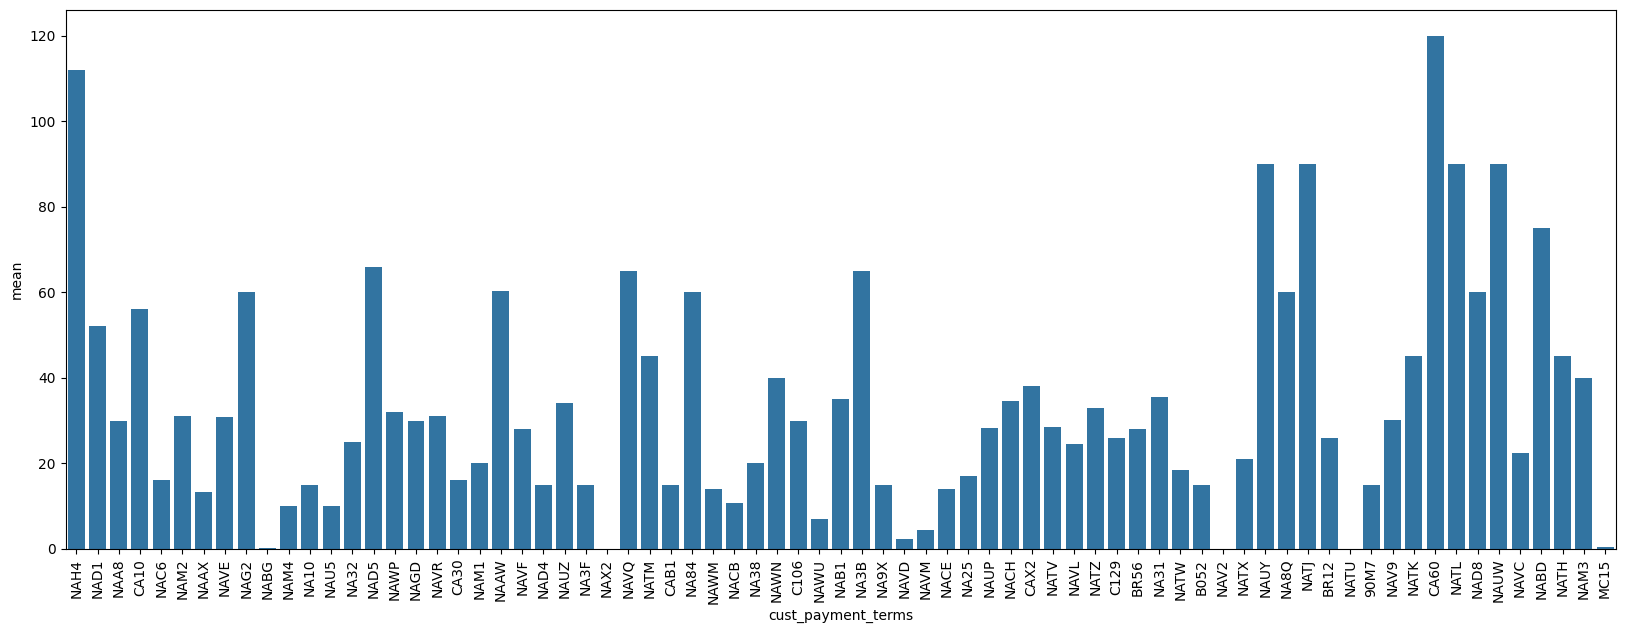

In [9]:
print(df['cust_payment_terms'].unique())
df['due_terms_on_invoice'] = pd.to_timedelta(df['due_in_date'] - df['posting_date']).dt.days

df = df.loc[df['due_terms_on_invoice'] >= 0]

terms_grouped = df.groupby('cust_payment_terms')['due_terms_on_invoice'].agg(['mean', 'min', 'max', 'count']).reset_index()

fig, ax = plt.subplots(figsize = [20, 7])
_ = sns.barplot(data = terms_grouped, x = 'cust_payment_terms', y = 'mean', ax = ax)
ax.set_xticklabels(rotation = 90, labels= df['cust_payment_terms'].unique() )

C:\Users\Corey\AppData\Local\Temp\ipykernel_16184\3975752270.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotation = 90, labels= df['cust_payment_terms'].unique() )


[Text(0, 0, 'NAH4'),
 Text(1, 0, 'NAD1'),
 Text(2, 0, 'NAA8'),
 Text(3, 0, 'CA10'),
 Text(4, 0, 'NAC6'),
 Text(5, 0, 'NAM2'),
 Text(6, 0, 'NAAX'),
 Text(7, 0, 'NAVE'),
 Text(8, 0, 'NAG2'),
 Text(9, 0, 'NABG'),
 Text(10, 0, 'NAM4'),
 Text(11, 0, 'NA10'),
 Text(12, 0, 'NAU5'),
 Text(13, 0, 'NA32'),
 Text(14, 0, 'NAD5'),
 Text(15, 0, 'NAWP'),
 Text(16, 0, 'NAGD'),
 Text(17, 0, 'NAVR'),
 Text(18, 0, 'CA30'),
 Text(19, 0, 'NAM1'),
 Text(20, 0, 'NAAW'),
 Text(21, 0, 'NAVF'),
 Text(22, 0, 'NAD4'),
 Text(23, 0, 'NAUZ'),
 Text(24, 0, 'NA3F'),
 Text(25, 0, 'NAX2'),
 Text(26, 0, 'NAVQ'),
 Text(27, 0, 'NATM'),
 Text(28, 0, 'CAB1'),
 Text(29, 0, 'NA84'),
 Text(30, 0, 'NAWM'),
 Text(31, 0, 'NACB'),
 Text(32, 0, 'NA38'),
 Text(33, 0, 'NAWN'),
 Text(34, 0, 'C106'),
 Text(35, 0, 'NAWU'),
 Text(36, 0, 'NAB1'),
 Text(37, 0, 'NA3B'),
 Text(38, 0, 'NA9X'),
 Text(39, 0, 'NAVD'),
 Text(40, 0, 'NAVM'),
 Text(41, 0, 'NACE'),
 Text(42, 0, 'NA25'),
 Text(43, 0, 'NAUP'),
 Text(44, 0, 'NACH'),
 Text(45, 0, 'CAX2')

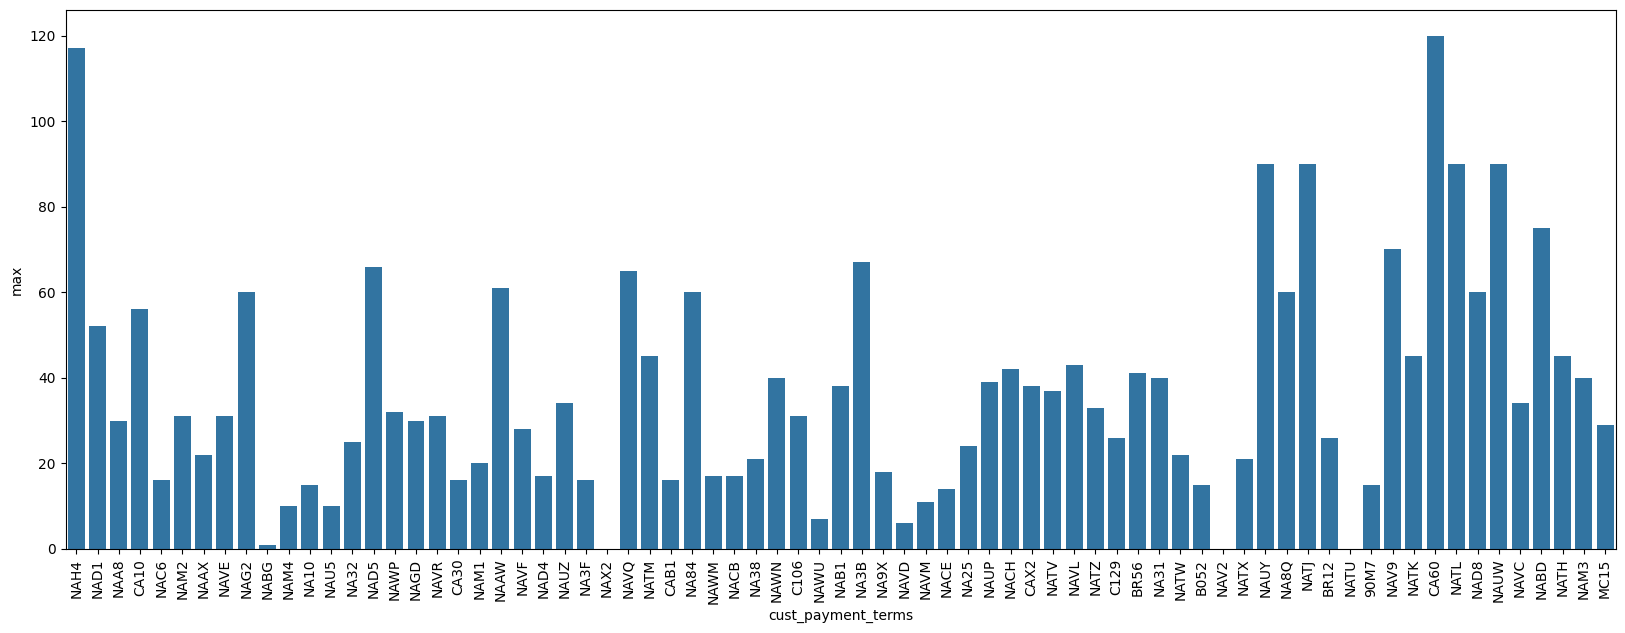

In [10]:
fig, ax = plt.subplots(figsize = [20, 7])
_ = sns.barplot(data = terms_grouped, x = 'cust_payment_terms', y = 'max', ax = ax)
ax.set_xticklabels(rotation = 90, labels= df['cust_payment_terms'].unique() )

In [11]:
df_paid = df.loc[~df['clear_date'].isna()]
df_paid['paid_date_diff'] = pd.to_timedelta(df_paid['clear_date'] - df_paid['due_in_date']).dt.days
df_paid_grouped = df_paid.groupby('cust_payment_terms')['paid_date_diff'].agg(['mean', 'min', 'max', 'count']).reset_index()

df_paid_grouped

,cust_payment_terms,mean,min,max,count
0,90M7,-41.800000,-87,-1,5
1,B052,-9.000000,-40,11,3
2,BR12,-2.500000,-5,0,2
3,BR56,4.600000,-1,14,10
4,C106,-0.666667,-4,2,12
...,...,...,...,...,...
65,NAWM,4.000000,4,4,4
66,NAWN,-3.123711,-69,90,97
67,NAWP,-8.238806,-9,-4,67
68,NAWU,-6.282051,-31,6,117


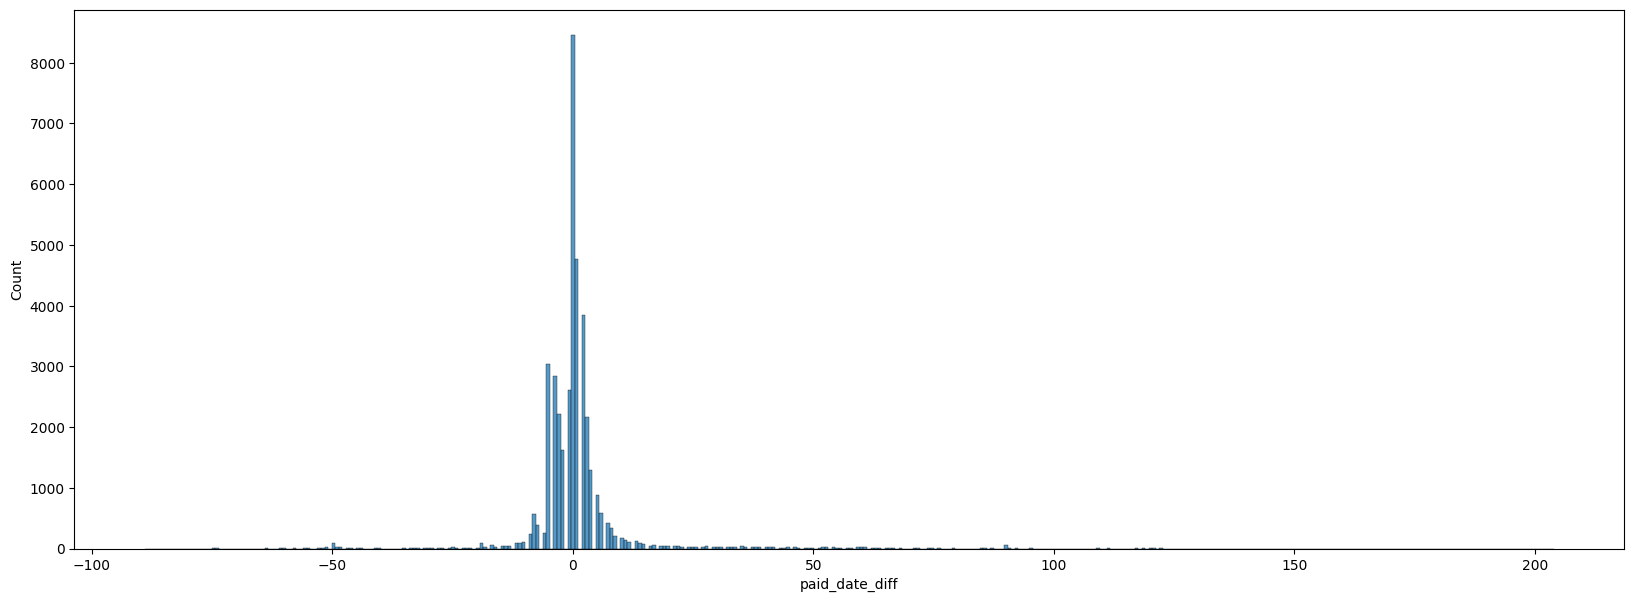

In [12]:
fig, ax = plt.subplots(figsize = [20, 7])
_ = sns.histplot(data = df_paid, x = 'paid_date_diff')

-3.0
2.0
5.0
-10.5
9.5


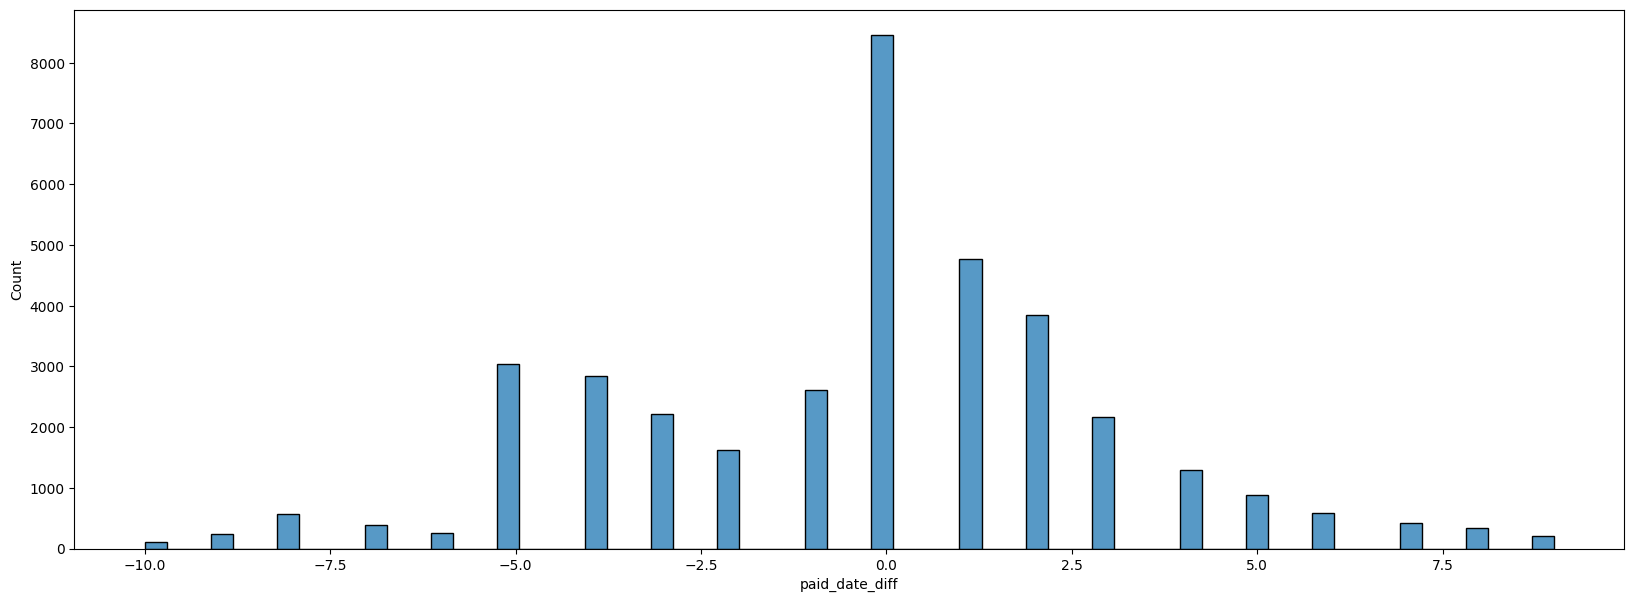

In [13]:
targ_var_lq = np.percentile(df_paid['paid_date_diff'], 25)
targ_var_uq = np.percentile(df_paid['paid_date_diff'], 75)
targ_var_iqr = targ_var_uq - targ_var_lq
targ_var_lt = targ_var_lq - (1.5 * targ_var_iqr)
targ_var_ut = targ_var_uq + (1.5 * targ_var_iqr)

print(targ_var_lq)
print(targ_var_uq)
print(targ_var_iqr)
print(targ_var_lt)
print(targ_var_ut)

df_paid_clean = df_paid.loc[df_paid['paid_date_diff'].between(targ_var_lt, targ_var_ut)]

fig, ax = plt.subplots(figsize = [20, 7])
_ = sns.histplot(data = df_paid_clean, x = 'paid_date_diff')

In [14]:
targ_var_std = np.std(df_paid['paid_date_diff'])
targ_var_mean = np.mean(df_paid['paid_date_diff'])

mean_plus_one_std = targ_var_mean + (targ_var_std)
mean_plus_two_std = targ_var_mean + (targ_var_std * 2)
mean_plus_three_std = targ_var_mean + (targ_var_std * 3)

mean_minus_one_std = targ_var_mean - (targ_var_std)
mean_minus_two_std = targ_var_mean - (targ_var_std * 2)
mean_minus_three_std = targ_var_mean - (targ_var_std * 3)

print(mean_minus_three_std)
print(mean_minus_two_std)
print(mean_minus_one_std)
print(targ_var_mean)
print(mean_plus_one_std)
print(mean_plus_two_std)
print(mean_plus_three_std)

-31.58253030901999
-20.783392983122564
-9.984255657225141
0.8148816686722824
11.614018994569705
22.413156320467127
33.21229364636456


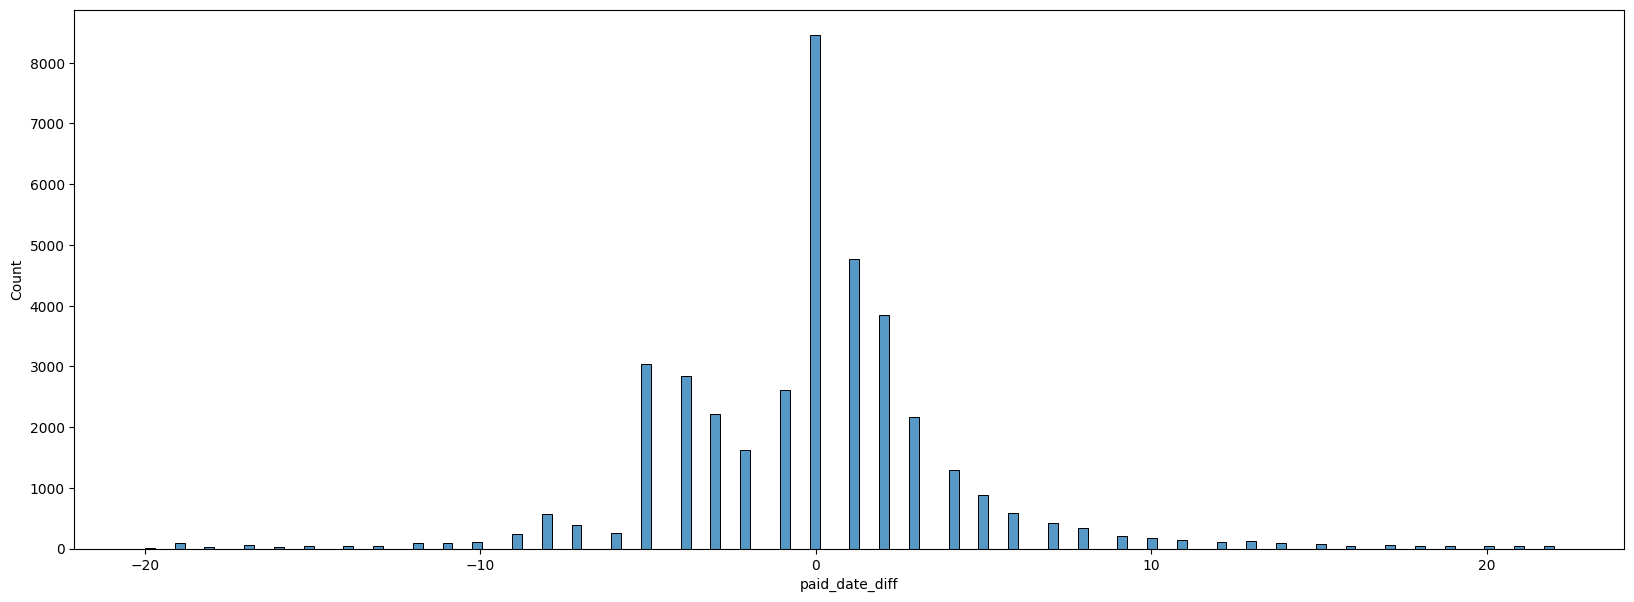

In [15]:
df_paid_clean = df_paid.loc[df_paid['paid_date_diff'].between(mean_minus_two_std, mean_plus_two_std)]

fig, ax = plt.subplots(figsize = [20, 7])
_ = sns.histplot(data = df_paid_clean, x = 'paid_date_diff')

In [16]:
df_paid_clean.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,doc_type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,is_open,due_terms_on_invoice,paid_date_diff
0,U001,0200769623,WAL-MAR corp,2020-02-11,2020.0,1930438491.0,2020-01-26,2020-01-25,2020-02-10,USD,RV,1.0,54273.28,20200126.0,NAH4,1930438491.0,0,15,1
1,U001,0200980828,BEN E,2019-08-08,2019.0,1929646410.0,2019-07-22,2019-07-22,2019-08-11,USD,RV,1.0,79656.60,20190722.0,NAD1,1929646410.0,0,20,-3
4,U001,0200769623,WAL-MAR foundation,2019-11-25,2019.0,1930147974.0,2019-11-13,2019-11-13,2019-11-28,USD,RV,1.0,33133.29,20191113.0,NAH4,1930147974.0,0,15,-3
6,U001,0200769623,WAL-MAR in,2019-11-12,2019.0,1930083373.0,2019-11-01,2019-10-31,2019-11-16,USD,RV,1.0,7358.49,20191101.0,NAH4,1930083373.0,0,15,-4
8,U001,0200769623,WAL-MAR corp,2019-06-18,2019.0,1929439637.0,2019-06-07,2019-06-05,2019-06-22,USD,RV,1.0,15995.04,20190607.0,NAH4,1929439637.0,0,15,-4


In [17]:
df_paid_clean = df_paid_clean.sort_values(['cust_number', 'document_create_date'])
df_paid_clean['invoice_count'] = df_paid_clean.groupby('cust_number')['invoice_id'].transform(lambda x: x.count())

df_paid_clean

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,doc_type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,is_open,due_terms_on_invoice,paid_date_diff,invoice_count
10487,U001,0100000051,GREE systems,2019-10-10,2019.0,1929850450.0,2019-09-09,2019-09-09,2019-10-09,USD,RV,1.0,37169.00,20190909.0,NAD5,1929850450.0,0,30,1,1
22254,U001,0100000158,CASC trust,2019-09-27,2019.0,1929465352.0,2019-06-12,2019-06-10,2019-09-10,USD,RV,1.0,57170.04,20190612.0,NAVM,1929465352.0,0,90,17,3
38143,U001,0100000158,CASC trust,2019-09-27,2019.0,1929465352.0,2019-06-12,2019-06-10,2019-09-10,USD,RV,1.0,57170.04,20190612.0,NAVM,1929465352.0,0,90,17,3
31866,U001,0100000158,CASC foundation,2019-09-27,2019.0,1929508202.0,2019-06-17,2019-06-17,2019-09-15,USD,RV,1.0,27179.53,20190617.0,NAVM,1929508202.0,0,90,12,3
6985,U001,0100000217,MRS S associates,2019-03-05,2019.0,1928792791.0,2019-02-19,2019-02-13,2019-03-06,USD,RV,1.0,34908.78,20190219.0,NAA8,1928792791.0,0,15,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26202,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,RV,1.0,16430.89,20200225.0,NAG2,1930554129.0,0,35,-4,113
26467,CA02,CCU013,KRAFT F corp,2019-05-31,2019.0,2960542066.0,2019-04-16,2019-04-16,2019-05-15,CAD,RV,1.0,19367.70,20190515.0,NAX2,2960542066.0,0,29,16,4
42509,CA02,CCU013,KRAFT F corp,2019-05-31,2019.0,2960542066.0,2019-04-16,2019-04-16,2019-05-15,CAD,RV,1.0,19367.70,20190515.0,NAX2,2960542066.0,0,29,16,4
7205,U001,CCU013,KRAFT F us,2019-12-20,2019.0,1930185327.0,2019-11-28,2019-11-22,2019-11-28,USD,RV,1.0,3846.48,20191128.0,NAX2,1930185327.0,0,0,22,4


In [18]:
print(len(df_paid_clean))
df_paid_clean = df_paid_clean.loc[df_paid_clean['invoice_count'] > 4]
df_paid_clean = df_paid_clean.sort_values(['cust_number', 'clear_date'])
for lag in range(4):
    df_paid_clean[f'paid_date_diff_lag_{lag + 1}'] = df_paid_clean.groupby('cust_number')['paid_date_diff'].shift(lag + 1)
df_paid_clean = df_paid_clean.dropna()
df_paid_clean['paid_date_diff_historic_wavg'] = (df_paid_clean['paid_date_diff_lag_4'] * 0.1) + (df_paid_clean['paid_date_diff_lag_3'] * 0.2) + (df_paid_clean['paid_date_diff_lag_2'] * 0.3) + (df_paid_clean['paid_date_diff_lag_1'] * 0.4) 
print(len(df_paid_clean))

38421
34987


In [19]:
df_paid_clean

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,...,invoice_id,is_open,due_terms_on_invoice,paid_date_diff,invoice_count,paid_date_diff_lag_1,paid_date_diff_lag_2,paid_date_diff_lag_3,paid_date_diff_lag_4,paid_date_diff_historic_wavg
45742,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,1928793044.0,0,15,-1,24,-2.0,-4.0,-3.0,-4.0,-3.0
28581,U001,0100000222,SMITHFIE trust,2019-03-11,2019.0,1928834382.0,2019-02-27,2019-02-21,2019-03-14,USD,...,1928834382.0,0,15,-3,24,-1.0,-2.0,-4.0,-3.0,-2.1
28576,U001,0100000222,SMITHFIE foundation,2019-03-18,2019.0,1928905151.0,2019-03-08,2019-03-05,2019-03-23,USD,...,1928905151.0,0,15,-5,24,-3.0,-1.0,-2.0,-4.0,-2.3
14033,U001,0100000222,SMITHFIE systems,2019-04-01,2019.0,1928999106.0,2019-03-21,2019-03-20,2019-04-05,USD,...,1928999106.0,0,15,-4,24,-5.0,-3.0,-1.0,-2.0,-3.3
18727,U001,0100000222,SMITHFIE trust,2019-04-22,2019.0,1929125545.0,2019-04-10,2019-04-10,2019-04-25,USD,...,1929125545.0,0,15,-3,24,-4.0,-5.0,-3.0,-1.0,-3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14968,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930516087.0,2020-02-15,2020-02-11,2020-03-21,USD,...,1930516087.0,0,35,6,113,12.0,15.0,19.0,-8.0,12.3
37300,U001,CCU002,KRFT FDS foundation,2020-03-27,2020.0,1930525134.0,2020-02-15,2020-02-13,2020-03-21,USD,...,1930525134.0,0,35,6,113,6.0,12.0,15.0,19.0,10.9
4817,U001,CCU002,KRFT FDS corp,2020-03-27,2020.0,1930538802.0,2020-02-20,2020-02-18,2020-03-26,USD,...,1930538802.0,0,35,1,113,6.0,6.0,12.0,15.0,8.1
3453,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930553706.0,2020-02-24,2020-02-21,2020-03-30,USD,...,1930553706.0,0,35,-3,113,1.0,6.0,6.0,12.0,4.6


In [20]:
df_list = []
for row in df_paid_clean.itertuples():
    invoice_id = row.invoice_id
    date_range = pd.date_range(start = row.document_create_date, end = row.clear_date)
    invoice_id_col = [invoice_id for x in range(len(date_range))]
    df_date_range = pd.DataFrame({'invoice_id': invoice_id_col, 'rolling_date': date_range})
    df_list.append(df_date_range)

dates_with_invoices = pd.concat(df_list)
dates_with_invoices.head()

,invoice_id,rolling_date
0,1928793044.0,2019-02-13
1,1928793044.0,2019-02-14
2,1928793044.0,2019-02-15
3,1928793044.0,2019-02-16
4,1928793044.0,2019-02-17


In [21]:
df_expanded_dates = df_paid_clean.merge(dates_with_invoices, how = 'inner', on = 'invoice_id')
df_expanded_dates['rolling_date'] = pd.to_datetime(df_expanded_dates['rolling_date']).dt.date
df_expanded_dates['days_to_pay'] = pd.to_timedelta(df_expanded_dates['clear_date'] - df_expanded_dates['rolling_date']).dt.days
df_expanded_dates['days_since_posted'] = pd.to_timedelta(df_expanded_dates['rolling_date'] - df_expanded_dates['document_create_date']).dt.days
df_expanded_dates['days_until_due'] = pd.to_timedelta(df_expanded_dates['due_in_date'] - df_expanded_dates['rolling_date']).dt.days
df_expanded_dates.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,...,invoice_count,paid_date_diff_lag_1,paid_date_diff_lag_2,paid_date_diff_lag_3,paid_date_diff_lag_4,paid_date_diff_historic_wavg,rolling_date,days_to_pay,days_since_posted,days_until_due
0,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,24,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-13,15,0,16
1,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,24,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-14,14,1,15
2,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,24,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-15,13,2,14
3,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,24,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-16,12,3,13
4,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,24,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-17,11,4,12


In [22]:
print(df_expanded_dates['clear_date'].max())
test_window_date = datetime(2020, 3, 1)

2020-05-06


In [23]:
customer_count_grouped = df_expanded_dates.groupby('name_customer').agg({'invoice_id': 'count', 'paid_date_diff': 'mean'}).reset_index()
customer_count_grouped.sort_values('invoice_id', ascending = False)

,name_customer,invoice_id,paid_date_diff
2278,WAL-MAR trust,13701,-2.147945
2275,WAL-MAR in,13427,-2.043048
2269,WAL-MAR,13126,-2.085860
2276,WAL-MAR llc,13120,-2.054345
2272,WAL-MAR corp,12907,-2.465871
...,...,...,...
1526,OMEGA AD,5,4.000000
1527,OMEGA AD corp,3,2.000000
1426,MID MO foundation,2,-14.000000
897,GREEN trust,1,-10.000000


In [24]:
customer_count_grouped.describe()

,invoice_id,paid_date_diff
count,2348.000000,2348.000000
mean,285.635434,1.014454
std,958.066809,4.017047
min,1.000000,-20.000000
25%,31.000000,-0.409960
50%,69.000000,0.823553
75%,203.000000,2.421585
max,13701.000000,22.000000


In [25]:
customer_count_grouped.loc[customer_count_grouped['invoice_id'] < 4]

,name_customer,invoice_id,paid_date_diff
896,GREEN corp,1,-10.0
897,GREEN trust,1,-10.0
1426,MID MO foundation,2,-14.0
1527,OMEGA AD corp,3,2.0


In [26]:
df_expanded_dates_cleaned = df_expanded_dates.copy()
df_expanded_dates_cleaned

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,...,invoice_count,paid_date_diff_lag_1,paid_date_diff_lag_2,paid_date_diff_lag_3,paid_date_diff_lag_4,paid_date_diff_historic_wavg,rolling_date,days_to_pay,days_since_posted,days_until_due
0,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,24,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-13,15,0,16
1,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,24,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-14,14,1,15
2,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,24,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-15,13,2,14
3,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,24,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-16,12,3,13
4,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,24,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-17,11,4,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670667,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,113,-3.0,1.0,6.0,6.0,0.9,2020-03-23,4,31,8
670668,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,113,-3.0,1.0,6.0,6.0,0.9,2020-03-24,3,32,7
670669,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,113,-3.0,1.0,6.0,6.0,0.9,2020-03-25,2,33,6
670670,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,113,-3.0,1.0,6.0,6.0,0.9,2020-03-26,1,34,5


In [27]:
df_expanded_dates_cleaned['invoice_priority'] = df_expanded_dates.groupby(['cust_number', 'rolling_date'])['days_since_posted'].rank(method = 'min', ascending = False)
df_expanded_dates_cleaned.sort_values(['cust_number', 'rolling_date'])

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,...,paid_date_diff_lag_1,paid_date_diff_lag_2,paid_date_diff_lag_3,paid_date_diff_lag_4,paid_date_diff_historic_wavg,rolling_date,days_to_pay,days_since_posted,days_until_due,invoice_priority
0,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-13,15,0,16,1.0
1,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-14,14,1,15,1.0
2,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-15,13,2,14,1.0
3,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-16,12,3,13,1.0
4,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-17,11,4,12,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670516,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930516087.0,2020-02-15,2020-02-11,2020-03-21,USD,...,12.0,15.0,19.0,-8.0,12.3,2020-03-27,0,45,-6,4.0
670560,U001,CCU002,KRFT FDS foundation,2020-03-27,2020.0,1930525134.0,2020-02-15,2020-02-13,2020-03-21,USD,...,6.0,12.0,15.0,19.0,10.9,2020-03-27,0,43,-6,5.0
670599,U001,CCU002,KRFT FDS corp,2020-03-27,2020.0,1930538802.0,2020-02-20,2020-02-18,2020-03-26,USD,...,6.0,6.0,12.0,15.0,8.1,2020-03-27,0,38,-1,6.0
670635,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930553706.0,2020-02-24,2020-02-21,2020-03-30,USD,...,1.0,6.0,6.0,12.0,4.6,2020-03-27,0,35,3,7.0


In [28]:
df_expanded_dates_cleaned

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,...,paid_date_diff_lag_1,paid_date_diff_lag_2,paid_date_diff_lag_3,paid_date_diff_lag_4,paid_date_diff_historic_wavg,rolling_date,days_to_pay,days_since_posted,days_until_due,invoice_priority
0,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-13,15,0,16,1.0
1,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-14,14,1,15,1.0
2,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-15,13,2,14,1.0
3,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-16,12,3,13,1.0
4,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,-2.0,-4.0,-3.0,-4.0,-3.0,2019-02-17,11,4,12,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670667,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,-3.0,1.0,6.0,6.0,0.9,2020-03-23,4,31,8,7.0
670668,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,-3.0,1.0,6.0,6.0,0.9,2020-03-24,3,32,7,7.0
670669,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,-3.0,1.0,6.0,6.0,0.9,2020-03-25,2,33,6,7.0
670670,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,-3.0,1.0,6.0,6.0,0.9,2020-03-26,1,34,5,7.0


In [29]:
# initiate lists for columns in mapping df
# mapping df should contain the id, rolling date and the nearest set date to that rolling date that isn't that invoice.
# invoice_id_list = []
# rolling_date_list = []
# last_invoice_set_list = []
# 
# for row in df_expanded_dates_cleaned.itertuples():
#     # we want to filter out customers other than the row in question, then ensure we're looking at other invoices from that customer, and then filtering anything before that given rolling date
#     df_filter = df_expanded_dates_cleaned.loc[(df_expanded_dates_cleaned['cust_number'] == row.cust_number)
#                                               & (df_expanded_dates_cleaned['invoice_id'] != row.invoice_id)
#                                               & (df_expanded_dates['document_create_date'] < row.rolling_date)]
#     invoice_id_list.append(row.invoice_id)
#     rolling_date_list.append(row.rolling_date)
#     if len(df_filter) == 0:
#         last_invoice_set_list.append(np.nan)
#     else:
#         last_invoice_set_list.append(df_filter['document_create_date'].max())
# 
#         
# 
# last_set_map = pd.DataFrame({'invoice_id': invoice_id_list, 'rolling_date': rolling_date_list, 'last_invoice_set_date': last_invoice_set_list})
# last_set_map
# 1. Ensure columns are proper datetimes
# 1. Clean and Sort

In [30]:
# define target vars
df_expanded_dates_cleaned['will_be_paid_within_35_days'] = np.where(df_expanded_dates_cleaned['days_to_pay'] <= 35, 1, 0)
df_expanded_dates_cleaned['will_be_paid_within_28_days'] = np.where(df_expanded_dates_cleaned['days_to_pay'] <= 28, 1, 0)
df_expanded_dates_cleaned['will_be_paid_within_21_days'] = np.where(df_expanded_dates_cleaned['days_to_pay'] <= 21, 1, 0)
df_expanded_dates_cleaned['will_be_paid_within_14_days'] = np.where(df_expanded_dates_cleaned['days_to_pay'] <= 14, 1, 0)
df_expanded_dates_cleaned['will_be_paid_within_7_days'] = np.where(df_expanded_dates_cleaned['days_to_pay'] <= 7, 1, 0)
df_expanded_dates_cleaned

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,...,rolling_date,days_to_pay,days_since_posted,days_until_due,invoice_priority,will_be_paid_within_35_days,will_be_paid_within_28_days,will_be_paid_within_21_days,will_be_paid_within_14_days,will_be_paid_within_7_days
0,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,2019-02-13,15,0,16,1.0,1,1,1,0,0
1,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,2019-02-14,14,1,15,1.0,1,1,1,1,0
2,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,2019-02-15,13,2,14,1.0,1,1,1,1,0
3,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,2019-02-16,12,3,13,1.0,1,1,1,1,0
4,U001,0100000222,SMITHFIE co,2019-02-28,2019.0,1928793044.0,2019-02-14,2019-02-13,2019-03-01,USD,...,2019-02-17,11,4,12,1.0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670667,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,2020-03-23,4,31,8,7.0,1,1,1,1,1
670668,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,2020-03-24,3,32,7,7.0,1,1,1,1,1
670669,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,2020-03-25,2,33,6,7.0,1,1,1,1,1
670670,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,...,2020-03-26,1,34,5,7.0,1,1,1,1,1


In [ ]:
unique_invoices = df_expanded_dates_cleaned.groupby('invoice_id')['document_create_date'].min().sort_values().index

# 2. Split the UNIQUE IDs
n_invoices = len(unique_invoices)
train_ids = unique_invoices[:int(n_invoices * 0.7)]
val_ids = unique_invoices[int(n_invoices * 0.7):int(n_invoices * 0.85)]
test_ids = unique_invoices[int(n_invoices * 0.85):]

# 3. Create sets based on those IDs
train = df_expanded_dates_cleaned[df_expanded_dates_cleaned['invoice_id'].isin(train_ids)]
val = df_expanded_dates_cleaned[df_expanded_dates_cleaned['invoice_id'].isin(val_ids)]
test = df_expanded_dates_cleaned[df_expanded_dates_cleaned['invoice_id'].isin(test_ids)]



In [32]:
# Train test split and feature selection

base_features = ['total_open_amount']
engineered_features = ['due_terms_on_invoice', 'paid_date_diff_lag_1', 'paid_date_diff_lag_2', 'paid_date_diff_lag_3', 'paid_date_diff_lag_4', 'paid_date_diff_historic_wavg', 'invoice_priority', 'days_since_posted', 'days_until_due']
features_overall = base_features + engineered_features
target_var = ['will_be_paid_within_7_days']

X = df_expanded_dates_cleaned[features_overall]
y = df_expanded_dates_cleaned[target_var]

train_X = train[features_overall]
train_y = train[target_var]

val_X = val[features_overall]
val_y = val[target_var]

test_X = test[features_overall]
test_y = test[target_var]

In [33]:
from xgboost import XGBClassifier


starter_params = {
    # Core Parameters
    'n_estimators': 250,           # Number of boosting rounds
    'learning_rate': 0.1,          # Step size shrinkage (eta)
    'max_depth': 6,                # Depth of the tree (range: 3-10)
    
    # Regularisation
    'min_child_weight': 1,         # Minimum sum of instance weight in a leaf
    'gamma': 0,                    # Minimum loss reduction for a split
    'subsample': 0.8,              # Use 80% of data per tree to prevent overfitting
    'colsample_bytree': 0.8,       # Use 80% of features per tree
    
    # Objective & Hardware
    'objective': 'binary:logistic', # For binary classification
    'n_jobs': -1,                  # Use all available CPU cores
    'random_state': 42,             # Ensure reproducibility
    'eval_metric': 'aucpr',
    'verbosity': 1,
    'early_stopping_rounds': 20
}

xgb = XGBClassifier(**starter_params)

In [34]:
xgb.fit(train_X, train_y, eval_set=[(train_X, train_y), (val_X, val_y)], verbose=True)

[0]	validation_0-aucpr:0.93830	validation_1-aucpr:0.93422
[1]	validation_0-aucpr:0.94409	validation_1-aucpr:0.94077
[2]	validation_0-aucpr:0.94850	validation_1-aucpr:0.94478
[3]	validation_0-aucpr:0.94967	validation_1-aucpr:0.94557
[4]	validation_0-aucpr:0.95283	validation_1-aucpr:0.94939
[5]	validation_0-aucpr:0.95370	validation_1-aucpr:0.95088
[6]	validation_0-aucpr:0.95498	validation_1-aucpr:0.95196
[7]	validation_0-aucpr:0.95520	validation_1-aucpr:0.95207
[8]	validation_0-aucpr:0.95527	validation_1-aucpr:0.95219
[9]	validation_0-aucpr:0.95544	validation_1-aucpr:0.95233
[10]	validation_0-aucpr:0.95570	validation_1-aucpr:0.95263
[11]	validation_0-aucpr:0.95594	validation_1-aucpr:0.95321
[12]	validation_0-aucpr:0.95609	validation_1-aucpr:0.95323
[13]	validation_0-aucpr:0.95661	validation_1-aucpr:0.95370
[14]	validation_0-aucpr:0.95684	validation_1-aucpr:0.95410
[15]	validation_0-aucpr:0.95735	validation_1-aucpr:0.95451
[16]	validation_0-aucpr:0.95793	validation_1-aucpr:0.95494
[17]	va

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

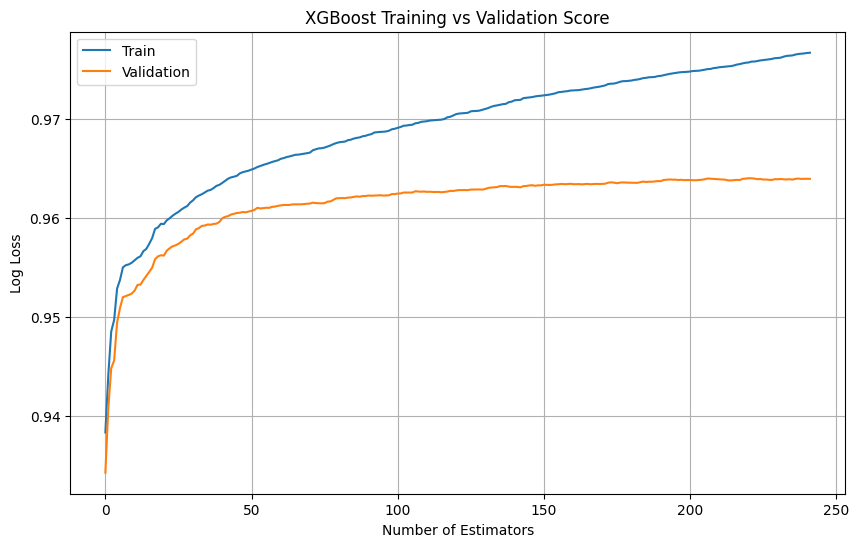

In [35]:
results = xgb.evals_result()

import matplotlib.pyplot as plt

# Extract metrics (assuming 'logloss' was used in your params)
train_loss = results['validation_0']['aucpr']
val_loss = results['validation_1']['aucpr']
epochs = range(len(train_loss))

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Train')
plt.plot(epochs, val_loss, label='Validation')

# Add details
plt.title('XGBoost Training vs Validation Score')
plt.xlabel('Number of Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
results_df = test_X.copy()
results_df['y'] = test_y
results_df['yhat_p'] = xgb.predict_proba(test_X)[:, 1]
results_df['yhat'] = np.where(results_df['yhat_p'] >= 0.5, 1, 0)

results_df

,total_open_amount,due_terms_on_invoice,paid_date_diff_lag_1,paid_date_diff_lag_2,paid_date_diff_lag_3,paid_date_diff_lag_4,paid_date_diff_historic_wavg,invoice_priority,days_since_posted,days_until_due,y,yhat_p,yhat
289,22259.92,15,-4.0,-4.0,-4.0,1.0,-3.5,1.0,0,20,0,0.008793,0
290,22259.92,15,-4.0,-4.0,-4.0,1.0,-3.5,1.0,1,19,0,0.009904,0
291,22259.92,15,-4.0,-4.0,-4.0,1.0,-3.5,1.0,2,18,0,0.010512,0
292,22259.92,15,-4.0,-4.0,-4.0,1.0,-3.5,1.0,3,17,0,0.015967,0
293,22259.92,15,-4.0,-4.0,-4.0,1.0,-3.5,1.0,4,16,0,0.031293,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
670667,16430.89,35,-3.0,1.0,6.0,6.0,0.9,7.0,31,8,1,0.435635,0
670668,16430.89,35,-3.0,1.0,6.0,6.0,0.9,7.0,32,7,1,0.642252,1
670669,16430.89,35,-3.0,1.0,6.0,6.0,0.9,7.0,33,6,1,0.751383,1
670670,16430.89,35,-3.0,1.0,6.0,6.0,0.9,7.0,34,5,1,0.808915,1


In [37]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix, roc_auc_score

test_prec = precision_score(results_df['y'], results_df['yhat'])
test_rec = recall_score(results_df['y'], results_df['yhat'])
test_roc_auc = roc_auc_score(results_df['y'], results_df['yhat'])
conf_mat = confusion_matrix(results_df['y'], results_df['yhat'])

print(test_prec)
print(test_rec)
print(test_roc_auc)

0.9012583836163388
0.932313903842584
0.9263731329638775


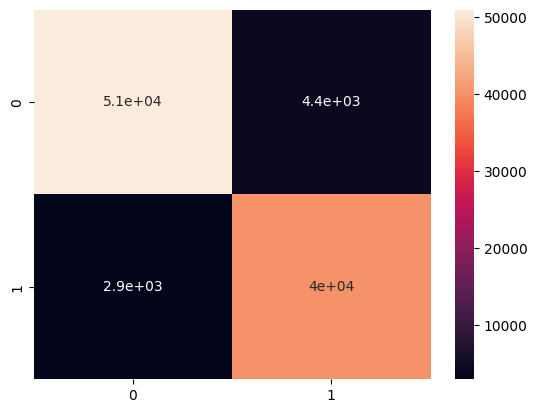

In [38]:
_ = sns.heatmap(conf_mat, annot = True)

In [39]:
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import f1_score

def objective(trial):
    # 1. Define Search Space
    params = {
        'n_estimators': 500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10), # Critical for imbalance
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'random_state': 42
    }

    # 2. Time-Based Manual Group Split 
    # (Training on older invoices, validating on the most recent set)
    split_point = int(len(df_expanded_dates_cleaned) * 0.8)
    
    # Identify unique invoices in the "future" period
    future_invoices = df_expanded_dates_cleaned.iloc[split_point:]['invoice_id'].unique()
    
    # Filter training data: invoices NOT in the future set to prevent leakage
    train_mask = ~df_expanded_dates_cleaned['invoice_id'].isin(future_invoices) & (df_expanded_dates_cleaned.index < split_point)
    valid_mask = df_expanded_dates_cleaned['invoice_id'].isin(future_invoices) & (df_expanded_dates_cleaned.index >= split_point)

    X_train, y_train = X[train_mask][features_overall], y[train_mask][target_var]
    X_valid, y_valid = X[valid_mask][features_overall], y[valid_mask][target_var]

    # 3. Fit Model with Early Stopping
    model = xgb.XGBClassifier(**params, early_stopping_rounds=20)
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

    # 4. Threshold Optimization (to fix that Confusion Matrix balance)
    probs = model.predict_proba(X_valid)[:, 1]
    threshold = 0.5
    preds = (probs >= threshold).astype(int)

    return f1_score(y_valid, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

c:\Users\Corey\personal_code\survivalboost_kaggle_trial\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-11 19:01:48,742] A new study created in memory with name: no-name-8a619c6c-6763-4d90-b0a7-c1cf9bb3bc11
[I 2026-05-11 19:01:51,808] Trial 0 finished with value: 0.8769377748936477 and parameters: {'learning_rate': 0.05337377930231199, 'max_depth': 7, 'subsample': 0.7725140871632735, 'colsample_bytree': 0.7537758622665816, 'scale_pos_weight': 6.934412219844086}. Best is trial 0 with value: 0.8769377748936477.
[I 2026-05-11 19:02:03,430] Trial 1 finished with value: 0.8748918685121108 and parameters: {'learning_rate': 0.02635947883403611, 'max_depth': 4, 'subsample': 0.6566730841871353, 'colsample_bytree': 0.6356153435399271, 'scale_pos_weight': 5.873526030435033}. Best is trial 0 with value: 0.876

In [40]:
print(study.best_params)

{'learning_rate': 0.03502539393501303, 'max_depth': 8, 'subsample': 0.782461454593415, 'colsample_bytree': 0.8960224079958751, 'scale_pos_weight': 1.668262122536212}


In [41]:
xgb = XGBClassifier(**study.best_params)

xgb.fit(train_X, train_y, eval_set=[(train_X, train_y), (val_X, val_y)], verbose=True)

results_df = test_X.copy()
results_df['y'] = test_y
results_df['yhat_p'] = xgb.predict_proba(test_X)[:, 1]
results_df['yhat'] = np.where(results_df['yhat_p'] >= 0.5, 1, 0)

test_prec = precision_score(results_df['y'], results_df['yhat'])
test_rec = recall_score(results_df['y'], results_df['yhat'])
test_roc_auc = roc_auc_score(results_df['y'], results_df['yhat'])
conf_mat = confusion_matrix(results_df['y'], results_df['yhat'])

print(test_prec)
print(test_rec)
print(test_roc_auc)

[0]	validation_0-logloss:0.68572	validation_1-logloss:0.68009
[1]	validation_0-logloss:0.65954	validation_1-logloss:0.65521
[2]	validation_0-logloss:0.63515	validation_1-logloss:0.63201
[3]	validation_0-logloss:0.61827	validation_1-logloss:0.61518
[4]	validation_0-logloss:0.59678	validation_1-logloss:0.59478
[5]	validation_0-logloss:0.57642	validation_1-logloss:0.57546
[6]	validation_0-logloss:0.55733	validation_1-logloss:0.55729
[7]	validation_0-logloss:0.54417	validation_1-logloss:0.54414
[8]	validation_0-logloss:0.52690	validation_1-logloss:0.52784
[9]	validation_0-logloss:0.51063	validation_1-logloss:0.51240
[10]	validation_0-logloss:0.49959	validation_1-logloss:0.50136
[11]	validation_0-logloss:0.48482	validation_1-logloss:0.48746
[12]	validation_0-logloss:0.48005	validation_1-logloss:0.48330
[13]	validation_0-logloss:0.46638	validation_1-logloss:0.47045
[14]	validation_0-logloss:0.45340	validation_1-logloss:0.45824
[15]	validation_0-logloss:0.44104	validation_1-logloss:0.44654
[1

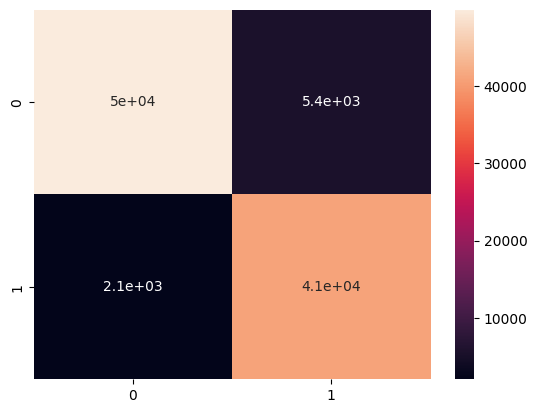

In [42]:
_ = sns.heatmap(conf_mat, annot = True)

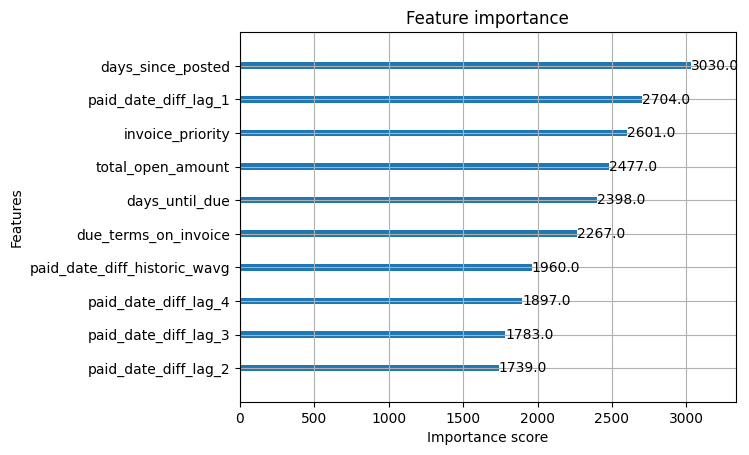

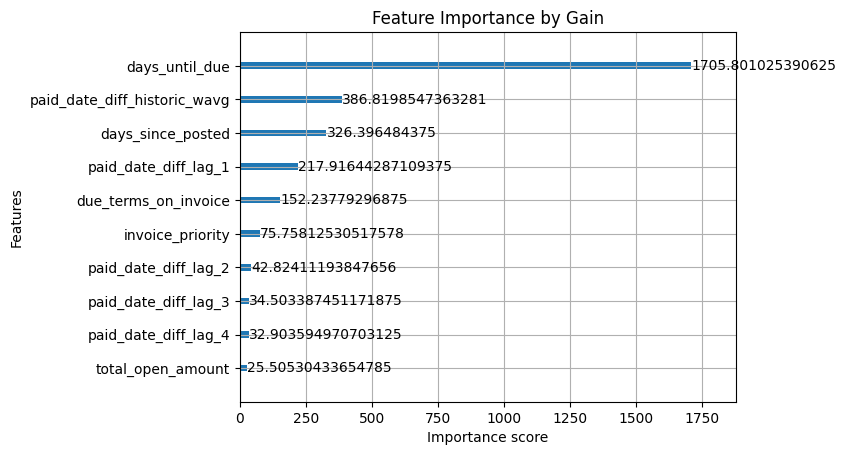

In [43]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# 1. Standard plot (shows "Weight" by default - frequency of splits)
plot_importance(xgb, max_num_features=15)
plt.show()

# 2. More informative plot (shows "Gain" - contribution to accuracy)
plot_importance(xgb, importance_type='gain', max_num_features=15)
plt.title("Feature Importance by Gain")
plt.show()